# Real-World Evaluation — CNN+LSTM + Mel Spectrogram


## Section 1 — Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.font_manager as fm
import urllib.request
from pydub import AudioSegment
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns



2026-09-29 21:59:18.007871: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-29 21:59:18.340105: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-29 21:59:21.562456: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import keras; print(keras.__version__)
import tensorflow as tf; print(tf.__version__)

3.12.1
2.20.0


In [3]:
SR          = 16000
HOP_LENGTH  = 512
N_FFT       = 2048
N_MELS      = 128
MAX_LEN     = 18
RANDOM_SEED = 42

MODEL_PATH = 'Models/cnnlstm_mel_model.h5'
UNSEEN_DIR = 'Unseen data/w1'

# Map folder name → Thai label (for display)
FOLDER_TO_THAI = {
    '01':'อา',  '02':'อี',  '03':'อือ', '04':'อู',
    '05':'เอ',  '06':'แอ',  '07':'โอ',  '08':'ออ',
    '09':'เออ', 's1':'อะ',  's2':'อิ',  's3':'อึ',
    's4':'อุ',  's5':'เอะ', 's6':'แอะ', 's7':'โอะ',
    's8':'เอาะ','s9':'เออะ'
}

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print('Setup complete.')

Setup complete.


## Section 2 — Load Model

In [4]:
from tensorflow.keras import layers
@tf.keras.utils.register_keras_serializable()
class BahdanauAttention(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, lstm_output):
        score   = self.V(tf.nn.tanh(self.W(lstm_output)))
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * lstm_output, axis=1)
        return context, weights

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.W.units})
        return config

In [5]:
# Patch Dense to ignore quantization_config
from keras.src.layers.core.dense import Dense
_original_init = Dense.__init__

def _patched_init(self, *args, **kwargs):
    kwargs.pop('quantization_config', None)
    _original_init(self, *args, **kwargs)

Dense.__init__ = _patched_init

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={"BahdanauAttention": BahdanauAttention}
)
print(f'Model loaded: {MODEL_PATH}')
print(f'Model input shape: {model.input_shape}')

I0000 00:00:1790693966.605567   16877 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model loaded: Models/cnnlstm_mel_model.h5
Model input shape: (None, 128, 18, 1)


In [6]:
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 18, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 18, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 18, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_6 (Permute)             │ (None, 18, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_6 (Reshape)             │ (None, 18, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 18, 512)        │     5,244,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 18, 512)        │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 18, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bahdanau_attention_6            │ [(None, 512), (None,   │       263,169 │
│ (BahdanauAttention)             │ 18, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 18)             │         9,234 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,635,733 (29.13 MB)

 Trainable params: 7,635,539 (29.13 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 2 (12.00 B)

## Section 3 — Load Unseen Data

In [7]:
data = []
for label in os.listdir(UNSEEN_DIR):
    folder = os.path.join(UNSEEN_DIR, label)
    if os.path.isdir(folder):
        for f in os.listdir(folder):
            if f.lower().endswith(('.wav', '.m4a')):
                data.append([os.path.join(folder, f), label])

df_unseen = pd.DataFrame(data, columns=['file_path', 'label'])
print(f'Total unseen samples : {len(df_unseen)}')
print(f'\nSamples per class:')
print(df_unseen['label'].value_counts().sort_index())

Total unseen samples : 54

Samples per class:
label
01    3
02    3
03    3
04    3
05    3
06    3
07    3
08    3
09    3
s1    3
s2    3
s3    3
s4    3
s5    3
s6    3
s7    3
s8    3
s9    3
Name: count, dtype: int64


## Section 4 — Preprocessing (smart_crop)

In [8]:
def detect_leading_silence(sound, silence_threshold=-30.0, chunk_size=10):
    trim_ms = 0
    while trim_ms < len(sound) and sound[trim_ms:trim_ms+chunk_size].dBFS < silence_threshold:
        trim_ms += chunk_size
    return trim_ms

def smart_crop(file_path, output_dir, window_ms=500, silence_threshold=-30.0):
    """Peak-energy crop — same as training pipeline."""
    os.makedirs(output_dir, exist_ok=True)
    sound = AudioSegment.from_file(file_path)
    start   = detect_leading_silence(sound, silence_threshold)
    end     = detect_leading_silence(sound.reverse(), silence_threshold)
    trimmed = sound[start:len(sound)-end]
    if len(trimmed) == 0: trimmed = sound
    energies = [trimmed[i:i+10].rms for i in range(0, len(trimmed), 10)]
    peak_ms  = int(np.argmax(energies)) * 10
    half = window_ms // 2
    final = trimmed[max(0, peak_ms-half):min(len(trimmed), peak_ms-half+window_ms)]
    out = os.path.join(output_dir, f'sc_{os.path.basename(file_path)}')
    final.export(out, format='wav')
    return out

In [9]:
def extract_mel(file_path, max_len=18):
    wave, _ = librosa.load(file_path, mono=True, sr=SR)
    mel    = librosa.feature.melspectrogram(y=wave, sr=SR,
                                             n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] < max_len:
        mel_db = np.pad(mel_db, ((0,0),(0, max_len - mel_db.shape[1])), mode='constant')
    else:
        mel_db = mel_db[:, :max_len]

    # Step 1: Global norm (เหมือนเดิม — เก็บ energy contour ไว้)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)

    # Step 2: CMVN เบาๆ ด้วย alpha=0.5 (ลด speaker bias แต่ไม่ลบ energy ทิ้ง)
    alpha  = 0.5
    mean   = mel_db.mean(axis=1, keepdims=True)
    std    = mel_db.std(axis=1,  keepdims=True) + 1e-6
    mel_db = mel_db - alpha * mean   # shift mean เท่านั้น ไม่หาร std

    return mel_db

## Section 5 — Extract Features

In [10]:
PROC_DIR_UNSEEN = 'proc_unseen/25_vowelword'

processed_paths = [
    smart_crop(fp, PROC_DIR_UNSEEN)
    for fp in tqdm(df_unseen['file_path'], desc='smart_crop')
]

X_unseen = np.array([
    extract_mel(p)
    for p in tqdm(processed_paths, desc='Mel extraction')
])

# LabelEncoder — fit ด้วย folder names เหมือนตอน train
le = LabelEncoder()
le.fit(sorted(FOLDER_TO_THAI.keys()))
y_unseen = le.transform(df_unseen['label'])

# display labels สำหรับ plot
display_labels = [FOLDER_TO_THAI[c] for c in le.classes_]

print(f'X_unseen shape : {X_unseen.shape}')
print(f'\nClass mapping:')
for i, c in enumerate(le.classes_):
    print(f'  class {i:2d} → {c} ({FOLDER_TO_THAI[c]})')

Mel extraction:   0%|                                                                            | 0/54 [00:00<?, ?it/s]/home/wara/anaconda3/envs/thesis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Mel extraction: 100%|███████████████████████████████████████████████████████████████████| 54/54 [00:03<00:00, 15.48it/s]

X_unseen shape : (54, 128, 18)

Class mapping:
  class  0 → 01 (อา)
  class  1 → 02 (อี)
  class  2 → 03 (อือ)
  class  3 → 04 (อู)
  class  4 → 05 (เอ)
  class  5 → 06 (แอ)
  class  6 → 07 (โอ)
  class  7 → 08 (ออ)
  class  8 → 09 (เออ)
  class  9 → s1 (อะ)
  class 10 → s2 (อิ)
  class 11 → s3 (อึ)
  class 12 → s4 (อุ)
  class 13 → s5 (เอะ)
  class 14 → s6 (แอะ)
  class 15 → s7 (โอะ)
  class 16 → s8 (เอาะ)
  class 17 → s9 (เออะ)


## Section 6 — Predict

In [11]:
X_unseen_input = X_unseen[..., np.newaxis]  # add channel dim

y_pred_prob = model.predict(X_unseen_input, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
confidence  = np.max(y_pred_prob, axis=1)

print(f'\nPredictions done : {len(y_pred)} samples')
print(f'Mean confidence  : {confidence.mean():.4f}')
print(f'Min confidence   : {confidence.min():.4f}')
print(f'Max confidence   : {confidence.max():.4f}')

2026-09-29 22:00:01.663138: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 403ms/step

Predictions done : 54 samples
Mean confidence  : 0.8473
Min confidence   : 0.3338
Max confidence   : 0.9266


## Section 7 — Evaluation Metrics

In [12]:
acc  = accuracy_score(y_unseen, y_pred)
f1   = f1_score(y_unseen, y_pred, average='macro')
f1_w = f1_score(y_unseen, y_pred, average='weighted')

print('='*50)
print('  REAL-WORLD TEST RESULTS')
print('='*50)
print(f'  Accuracy (overall) : {acc*100:.2f}%')
print(f'  Macro F1           : {f1:.4f}')
print(f'  Weighted F1        : {f1_w:.4f}')
print(f'  Total samples      : {len(y_unseen)}')
print('='*50)
print()

# Get the unique labels present in y_unseen
unique_labels = np.unique(y_unseen)
# Filter display_labels to only include those corresponding to unique_labels
filtered_display_labels = [display_labels[i] for i in unique_labels]

print(classification_report(y_unseen, y_pred, labels=unique_labels, target_names=filtered_display_labels))

  REAL-WORLD TEST RESULTS
  Accuracy (overall) : 92.59%
  Macro F1           : 0.9238
  Weighted F1        : 0.9238
  Total samples      : 54

              precision    recall  f1-score   support

          อา       0.75      1.00      0.86         3
          อี       1.00      1.00      1.00         3
         อือ       1.00      1.00      1.00         3
          อู       0.75      1.00      0.86         3
          เอ       1.00      0.67      0.80         3
          แอ       1.00      0.67      0.80         3
          โอ       1.00      0.67      0.80         3
          ออ       1.00      1.00      1.00         3
         เออ       0.75      1.00      0.86         3
          อะ       1.00      1.00      1.00         3
          อิ       1.00      1.00      1.00         3
          อึ       1.00      1.00      1.00         3
          อุ       1.00      0.67      0.80         3
         เอะ       1.00      1.00      1.00         3
         แอะ       1.00      1.00      1.00   

## Section 8 — Per-Class Accuracy

In [13]:
per_class = []
for i, folder in enumerate(le.classes_):
    mask = y_unseen == i
    if mask.sum() == 0: continue
    cls_acc  = accuracy_score(y_unseen[mask], y_pred[mask])
    cls_conf = confidence[mask].mean()
    per_class.append({
        'Vowel'          : FOLDER_TO_THAI[folder],
        'Samples'        : int(mask.sum()),
        'Accuracy'       : f'{cls_acc*100:.1f}%',
        'Mean Confidence': f'{cls_conf:.4f}',
    })

df_per_class = pd.DataFrame(per_class)
print(df_per_class.to_string(index=False))

Vowel  Samples Accuracy Mean Confidence
   อา        3   100.0%          0.8931
   อี        3   100.0%          0.7985
  อือ        3   100.0%          0.8830
   อู        3   100.0%          0.8543
   เอ        3    66.7%          0.9044
   แอ        3    66.7%          0.6995
   โอ        3    66.7%          0.7882
   ออ        3   100.0%          0.6459
  เออ        3   100.0%          0.8968
   อะ        3   100.0%          0.9249
   อิ        3   100.0%          0.8808
   อึ        3   100.0%          0.8851
   อุ        3    66.7%          0.7332
  เอะ        3   100.0%          0.9043
  แอะ        3   100.0%          0.8866
  โอะ        3   100.0%          0.9207
 เอาะ        3   100.0%          0.8490
 เออะ        3   100.0%          0.9027


## Section 9 — Confusion Matrix

In [14]:
urllib.request.urlretrieve(
    'https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf',
    'Sarabun-Regular.ttf'
)
fm.fontManager.addfont('Sarabun-Regular.ttf')
plt.rcParams['font.family'] = 'Sarabun'

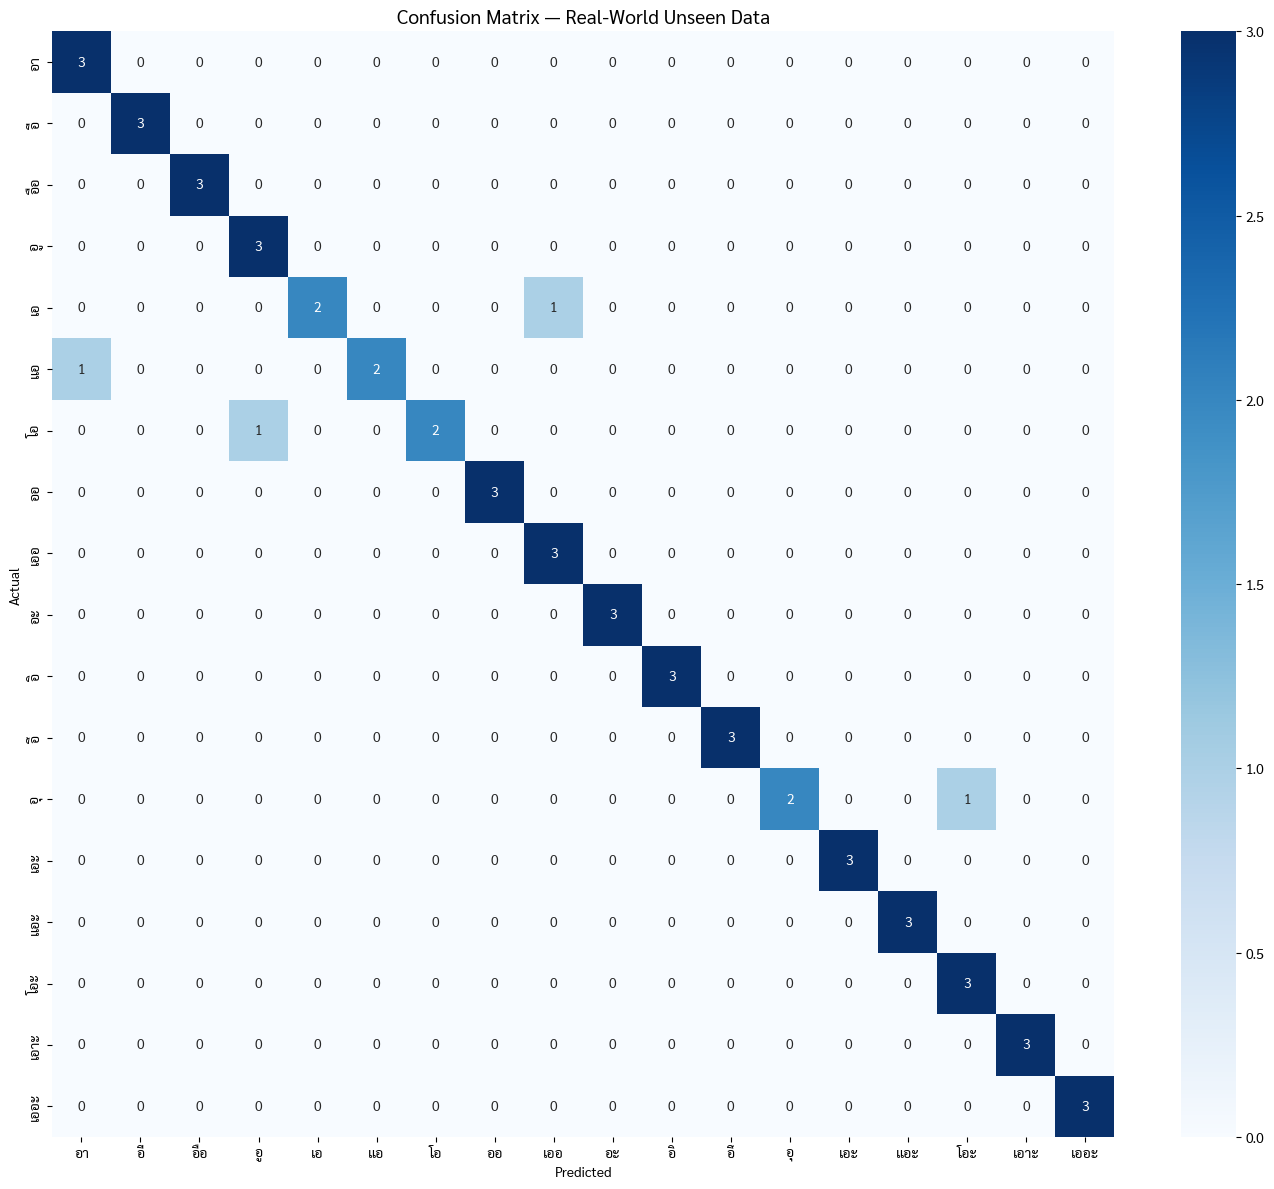

In [15]:
cm = confusion_matrix(y_unseen, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=display_labels, yticklabels=display_labels)
plt.title('Confusion Matrix — Real-World Unseen Data', fontsize=14)
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/realworld_cm.png', dpi=150)
plt.show()

## Section 10 — Save Predictions CSV

In [16]:
df_results = df_unseen.copy()
df_results['true_label']      = df_unseen['label'].map(FOLDER_TO_THAI)
df_results['predicted_label'] = [FOLDER_TO_THAI[le.classes_[i]] for i in y_pred]
df_results['confidence']      = confidence.round(4)
df_results['correct']         = (y_pred == y_unseen)

# เพิ่ม probability ของแต่ละ class
prob_df = pd.DataFrame(
    y_pred_prob.round(4),
    columns=[f'prob_{FOLDER_TO_THAI[c]}' for c in le.classes_]
)
df_results = pd.concat([df_results.reset_index(drop=True), prob_df], axis=1)

df_results.to_csv('results/25_vowelword_realworld.csv',index=False, encoding='utf-8-sig')

print(f'Real-world | Acc: {acc*100:.2f}% | Macro F1: {f1:.4f} | Weighted F1: {f1_w:.4f} | Samples: {len(y_unseen)}')

Real-world | Acc: 92.59% | Macro F1: 0.9238 | Weighted F1: 0.9238 | Samples: 54


## Section 11 — Grad-CAM (บันทึกภาพแยกโฟลเดอร์ correct / incorrect)

In [17]:
SPEAKER_ID  = '25_vowelword'
GRADCAM_DIR = f'gradcam/{SPEAKER_ID}'
os.makedirs(os.path.join(GRADCAM_DIR, 'correct'),   exist_ok=True)
os.makedirs(os.path.join(GRADCAM_DIR, 'incorrect'), exist_ok=True)

# ── หา Conv2D layer สุดท้ายก่อนเข้า LSTM — ใช้เป็น target ของ Grad-CAM ──
last_conv_layer_name = None
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
assert last_conv_layer_name is not None, 'ไม่พบ Conv2D layer ใน model'
print(f'Grad-CAM target layer: {last_conv_layer_name}')

grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[model.get_layer(last_conv_layer_name).output, model.output]
)

def make_gradcam_heatmap(img_array, pred_index):
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def save_gradcam_overlay(mel_db, heatmap, out_path, title):
    # ขยาย heatmap (ขนาด feature map) ให้เท่ากับ mel spectrogram ต้นฉบับ
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis], (mel_db.shape[0], mel_db.shape[1])
    ).numpy().squeeze()

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(mel_db, aspect='auto', origin='lower', cmap='gray_r')
    ax.imshow(heatmap_resized, aspect='auto', origin='lower', cmap='jet', alpha=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Time frame')
    ax.set_ylabel('Mel bin')
    plt.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)

for i in tqdm(range(len(X_unseen)), desc='Grad-CAM'):
    img_array = X_unseen_input[i:i+1]
    heatmap   = make_gradcam_heatmap(img_array, pred_index=int(y_pred[i]))

    is_correct = bool(y_pred[i] == y_unseen[i])
    subfolder  = 'correct' if is_correct else 'incorrect'
    true_th    = FOLDER_TO_THAI[df_unseen['label'].iloc[i]]
    pred_th    = FOLDER_TO_THAI[le.classes_[y_pred[i]]]
    base_name  = os.path.splitext(os.path.basename(df_unseen['file_path'].iloc[i]))[0]

    out_name = f"{base_name}__true-{true_th}__pred-{pred_th}__conf-{confidence[i]:.2f}.png"
    out_path = os.path.join(GRADCAM_DIR, subfolder, out_name)

    title = f'True: {true_th} | Pred: {pred_th} | Conf: {confidence[i]:.2f} ({"correct" if is_correct else "incorrect"})'
    save_gradcam_overlay(X_unseen[i], heatmap, out_path, title)

n_correct = int((y_pred == y_unseen).sum())
n_total   = len(y_unseen)
print(f'Grad-CAM saved: {n_correct} correct   -> {GRADCAM_DIR}/correct/')
print(f'                {n_total - n_correct} incorrect -> {GRADCAM_DIR}/incorrect/')

Grad-CAM target layer: conv2d_13


Grad-CAM:   0%|                                                                                  | 0/54 [00:00<?, ?it/s]/home/wara/anaconda3/envs/thesis/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_6']
Received: inputs=Tensor(shape=(1, 128, 18, 1))
  warnings.warn(msg)
Grad-CAM: 100%|█████████████████████████████████████████████████████████████████████████| 54/54 [01:12<00:00,  1.34s/it]

Grad-CAM saved: 50 correct   -> gradcam/25_vowelword/correct/
                4 incorrect -> gradcam/25_vowelword/incorrect/
